In [1]:
# Cell 1: Setup and Imports
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports loaded successfully!")
print(f"   XGBoost version: {xgb.__version__}")
print(f"   LightGBM version: {lgb.__version__}")

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/100.2 MB 2.7 MB/s eta 0:00:37
   ---------------------------------------- 1.0/100.2 MB 16.0 MB/s eta 0:00:07
    --------------------------------------- 2.4/100.2 MB 18.8 MB/s eta 0:00:06
   - -------------------------------------- 3.6/100.2 MB 21.1 MB/s eta 0:00:05
   - -------------------------------------- 4.8/100.2 MB 23.6 MB/s eta 0:00:05
   -- ------------------------------------- 6.5/100.2 MB 26.1 MB/s eta 0:00:04
   --- ------------------------------------ 7.8/100.2 MB 26.2 MB/s eta 0:00:04
   --- ------------------------------------ 9.3/100.2 MB 27.1 MB/s eta 0:00:04
   ---- ----------------------------------- 10.7/100.2 MB 31.1 MB/s eta 0:00:03
   ---- ----------------------------------- 10.8/100.2 MB 28.4 MB/s eta 0:00:04
   ---- ----------------------------------- 11.1/100.2 MB 26.2 MB/s eta 0:00:04
   ---- ----------------------------------- 12.4/100.2 MB 

In [2]:
# Cell 2: Load Engineered Dataset
print("="*70)
print("📂 LOADING ENGINEERED DATASET")
print("="*70)

# Load data from Notebook 2
data = pd.read_csv('engineered_dataset.csv')
print(f"✅ Loaded dataset with {len(data):,} rows and {len(data.columns)} columns")

# Identify features and target
target_col = 'churned'
feature_cols = [col for col in data.columns if col != target_col and col != 'customer_id']

# Remove high-cardinality or non-numeric if any
feature_cols = [col for col in feature_cols if data[col].dtype in ['int64', 'float64', 'bool']]

X = data[feature_cols]
y = data[target_col]

print(f"\n📊 Dataset Info:")
print(f"   Features: {len(feature_cols)}")
print(f"   Target distribution:")
print(f"      Not Churned: {(y==0).sum():,} ({(y==0).mean():.1%})")
print(f"      Churned: {(y==1).sum():,} ({(y==1).mean():.1%})")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📊 Train/Test Split:")
print(f"   Training: {len(X_train):,} samples")
print(f"   Testing: {len(X_test):,} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")

📂 LOADING ENGINEERED DATASET
✅ Loaded dataset with 10,000 rows and 63 columns

📊 Dataset Info:
   Features: 56
   Target distribution:
      Not Churned: 8,314 (83.1%)
      Churned: 1,686 (16.9%)

📊 Train/Test Split:
   Training: 8,000 samples
   Testing: 2,000 samples
✅ Features scaled using StandardScaler


In [3]:
# Cell 3: Define Models to Benchmark
print("="*70)
print("🤖 DEFINING MODELS FOR BENCHMARK")
print("="*70)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1),
    'K-Neighbors': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

print(f"✅ Loaded {len(models)} models for benchmarking:")
for name in models.keys():
    print(f"   - {name}")

🤖 DEFINING MODELS FOR BENCHMARK
✅ Loaded 9 models for benchmarking:
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - Gradient Boosting
   - XGBoost
   - LightGBM
   - K-Neighbors
   - SVM
   - Naive Bayes


In [4]:
# Cell 4: Train and Evaluate All Models
print("="*70)
print("📊 TRAINING AND EVALUATING MODELS")
print("="*70)

results = []

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba) if hasattr(model, 'predict_proba') else 0
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    print(f"   ✅ Accuracy: {accuracy:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}")

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*70)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*70)
print(results_df.round(4).to_string(index=False))

📊 TRAINING AND EVALUATING MODELS

🔄 Training Logistic Regression...
   ✅ Accuracy: 0.9995 | AUC: 1.0000 | F1: 0.9985

🔄 Training Decision Tree...
   ✅ Accuracy: 1.0000 | AUC: 1.0000 | F1: 1.0000

🔄 Training Random Forest...
   ✅ Accuracy: 1.0000 | AUC: 1.0000 | F1: 1.0000

🔄 Training Gradient Boosting...
   ✅ Accuracy: 1.0000 | AUC: 1.0000 | F1: 1.0000

🔄 Training XGBoost...
   ✅ Accuracy: 1.0000 | AUC: 1.0000 | F1: 1.0000

🔄 Training LightGBM...
   ✅ Accuracy: 1.0000 | AUC: 1.0000 | F1: 1.0000

🔄 Training K-Neighbors...
   ✅ Accuracy: 0.8845 | AUC: 0.8704 | F1: 0.5075

🔄 Training SVM...
   ✅ Accuracy: 0.9970 | AUC: 0.9999 | F1: 0.9910

🔄 Training Naive Bayes...
   ✅ Accuracy: 1.0000 | AUC: 1.0000 | F1: 1.0000

📊 MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC  CV Mean  CV Std
      Decision Tree    1.0000     1.0000  1.0000    1.0000   1.0000   0.9999  0.0002
      Random Forest    1.0000     1.0000  1.0000    1.0000   1.0000   0.9999  0.0

📈 PERFORMANCE VISUALIZATION


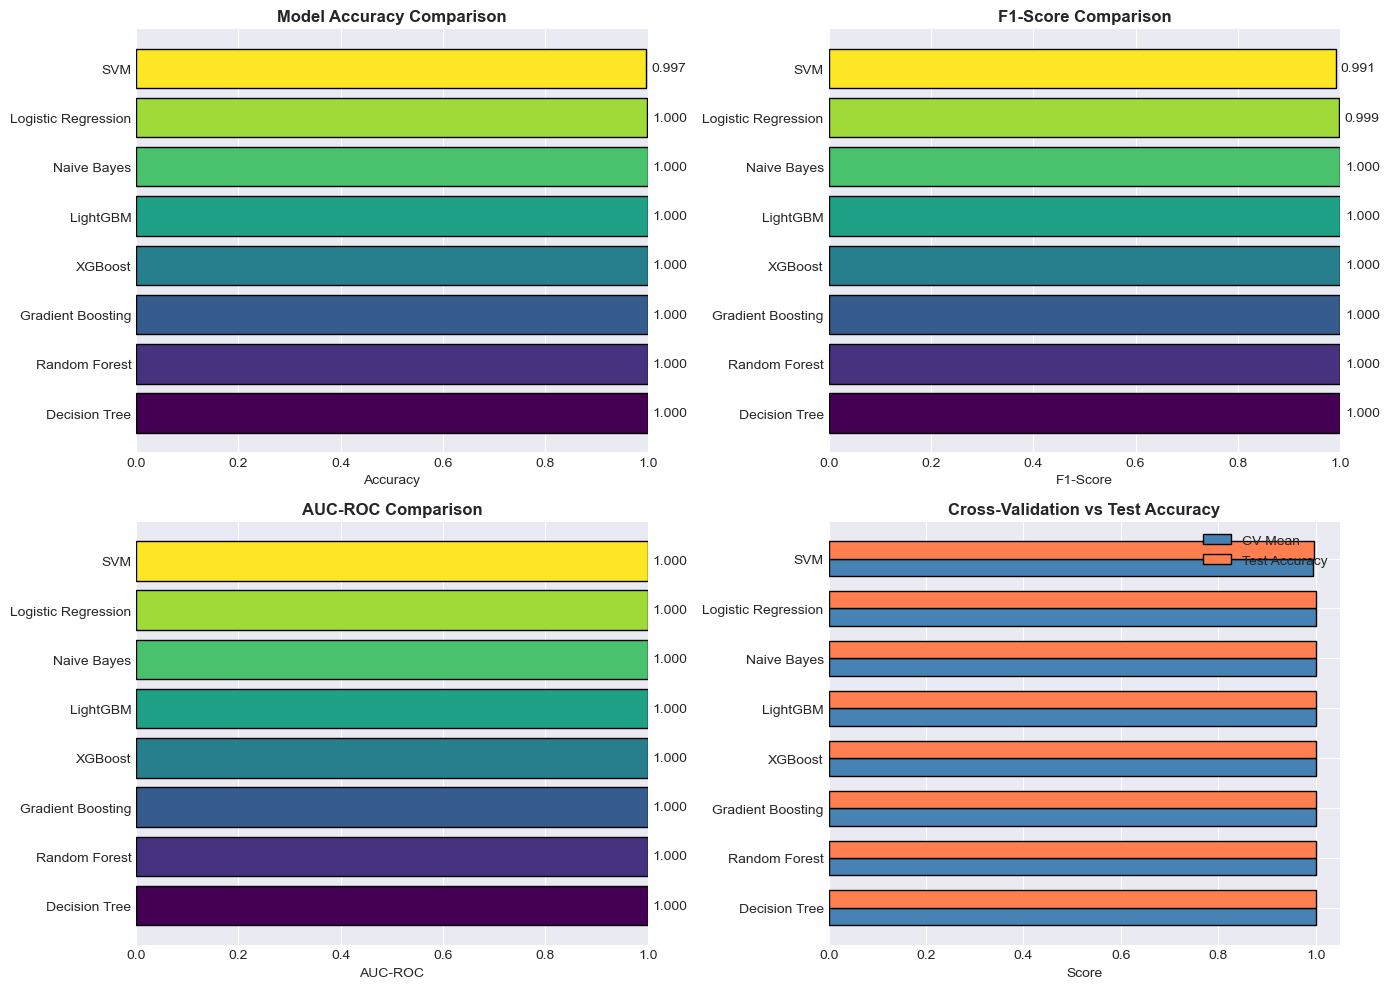

✅ Saved: model_comparison.png


In [5]:
# Cell 5: Performance Visualization
print("="*70)
print("📈 PERFORMANCE VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Comparison
ax1 = axes[0, 0]
top_models = results_df.head(8)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_models)))
bars = ax1.barh(top_models['Model'], top_models['Accuracy'], color=colors, edgecolor='black')
ax1.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xlabel('Accuracy')
ax1.set_xlim(0, 1)
for bar, val in zip(bars, top_models['Accuracy']):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# 2. F1-Score Comparison
ax2 = axes[0, 1]
bars = ax2.barh(top_models['Model'], top_models['F1-Score'], color=colors, edgecolor='black')
ax2.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax2.set_xlabel('F1-Score')
ax2.set_xlim(0, 1)
for bar, val in zip(bars, top_models['F1-Score']):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# 3. AUC-ROC Comparison
ax3 = axes[1, 0]
bars = ax3.barh(top_models['Model'], top_models['AUC-ROC'], color=colors, edgecolor='black')
ax3.set_title('AUC-ROC Comparison', fontsize=12, fontweight='bold')
ax3.set_xlabel('AUC-ROC')
ax3.set_xlim(0, 1)
for bar, val in zip(bars, top_models['AUC-ROC']):
    ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# 4. Cross-Validation Scores
ax4 = axes[1, 1]
x = np.arange(len(top_models))
width = 0.35
ax4.barh(x - width/2, top_models['CV Mean'], width, label='CV Mean', color='steelblue', edgecolor='black')
ax4.barh(x + width/2, top_models['Accuracy'], width, label='Test Accuracy', color='coral', edgecolor='black')
ax4.set_yticks(x)
ax4.set_yticklabels(top_models['Model'])
ax4.set_title('Cross-Validation vs Test Accuracy', fontsize=12, fontweight='bold')
ax4.set_xlabel('Score')
ax4.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison.png")

🏆 BEST MODEL DETAILED ANALYSIS
🏆 Best Model: Decision Tree

📊 Performance Metrics:
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000
   AUC-ROC:   1.0000


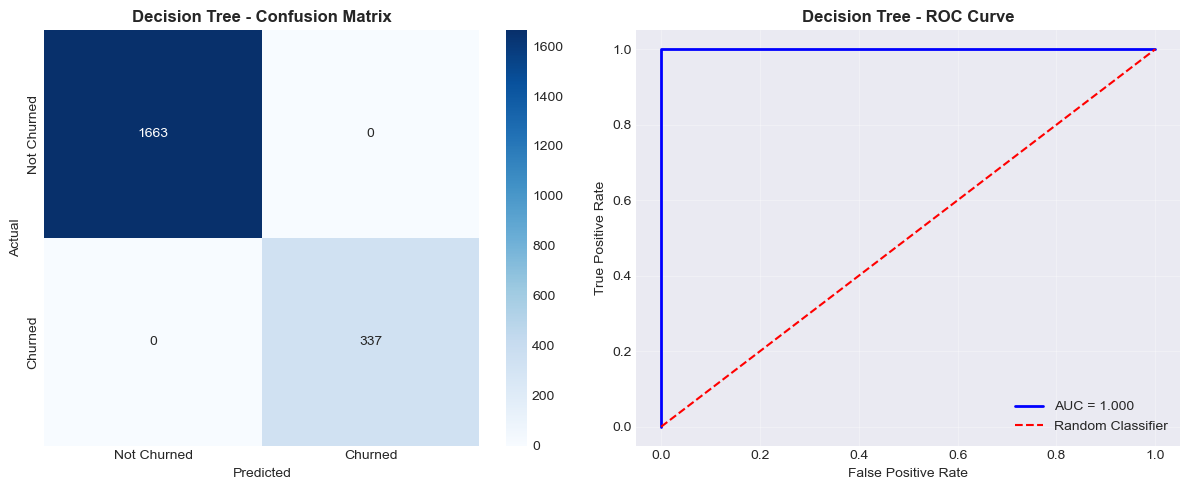

✅ Saved: best_model_analysis.png

📋 Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00      1663
     Churned       1.00      1.00      1.00       337

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [6]:
# Cell 6: Best Model Detailed Analysis
print("="*70)
print("🏆 BEST MODEL DETAILED ANALYSIS")
print("="*70)

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"🏆 Best Model: {best_model_name}")
print(f"\n📊 Performance Metrics:")
print(f"   Accuracy:  {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"   Recall:    {results_df.iloc[0]['Recall']:.4f}")
print(f"   F1-Score:  {results_df.iloc[0]['F1-Score']:.4f}")
print(f"   AUC-ROC:   {results_df.iloc[0]['AUC-ROC']:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix Heatmap
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
ax1.set_title(f'{best_model_name} - Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# ROC Curve
ax2 = axes[1]
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {results_df.iloc[0]["AUC-ROC"]:.3f}')
ax2.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
ax2.set_title(f'{best_model_name} - ROC Curve', fontsize=12, fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: best_model_analysis.png")

# Classification Report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Not Churned', 'Churned']))

🔍 FEATURE IMPORTANCE ANALYSIS
📊 Top 10 Most Important Features (Decision Tree):
   customer_lifetime_value: 1.0000
   age: 0.0000
   membership_tier_target_encoded: 0.0000
   age_group_18-25: 0.0000
   age_group_26-35: 0.0000
   age_group_36-50: 0.0000
   age_group_51-65: 0.0000
   age_group_65+: 0.0000
   income_tier_Low: 0.0000
   income_tier_Medium: 0.0000


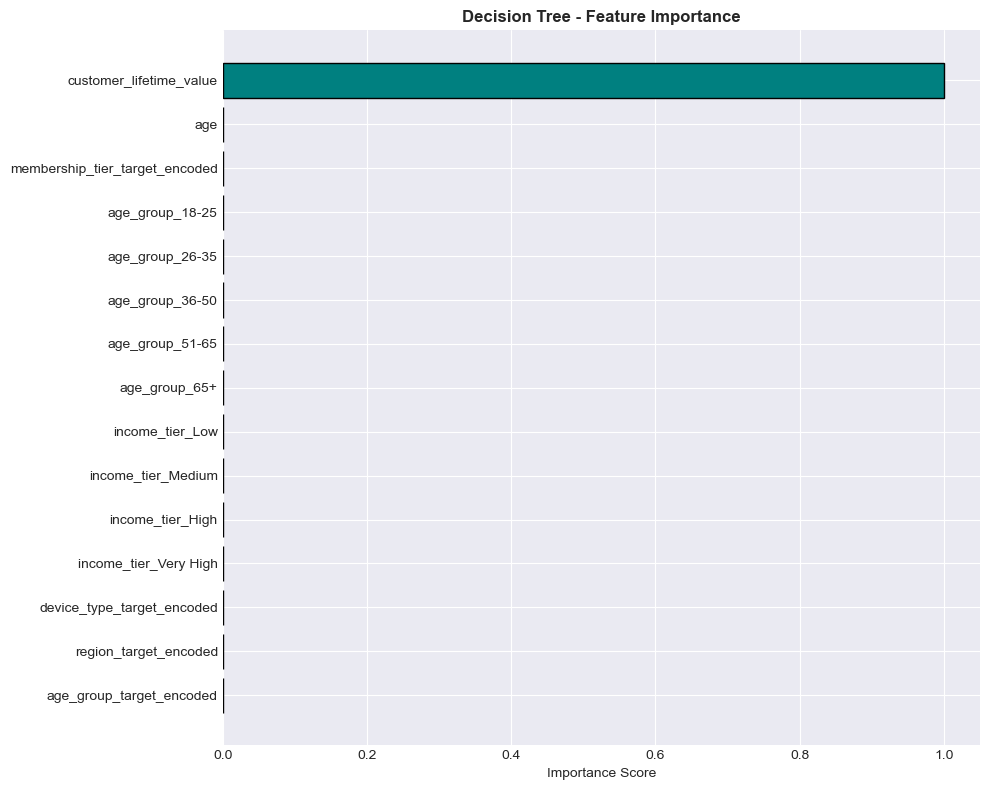

✅ Saved: feature_importance_best_model.png


In [7]:
# Cell 7: Feature Importance Analysis
print("="*70)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Check if best model has feature_importances_
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print(f"📊 Top 10 Most Important Features ({best_model_name}):")
    for i, row in importance_df.head(10).iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")
    
    # Visualization
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(15)
    plt.barh(top_features['feature'], top_features['importance'], color='teal', edgecolor='black')
    plt.xlabel('Importance Score')
    plt.title(f'{best_model_name} - Feature Importance', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance_best_model.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: feature_importance_best_model.png")
else:
    print(f"⚠️ {best_model_name} does not provide feature importances")

In [8]:
# Cell 8: Save Best Model
print("="*70)
print("💾 SAVING BEST MODEL")
print("="*70)

import joblib

# Save the best model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'model_scaler.pkl')

# Save model metadata
model_metadata = {
    'best_model_name': best_model_name,
    'accuracy': float(results_df.iloc[0]['Accuracy']),
    'precision': float(results_df.iloc[0]['Precision']),
    'recall': float(results_df.iloc[0]['Recall']),
    'f1_score': float(results_df.iloc[0]['F1-Score']),
    'auc_roc': float(results_df.iloc[0]['AUC-ROC']),
    'features': feature_cols,
    'num_features': len(feature_cols)
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("✅ Saved:")
print("   - best_model.pkl")
print("   - model_scaler.pkl")
print("   - model_metadata.json")

💾 SAVING BEST MODEL
✅ Saved:
   - best_model.pkl
   - model_scaler.pkl
   - model_metadata.json


In [9]:
# Cell 9: Notebook Completion Summary
print("="*70)
print("🎉 NOTEBOOK 3 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    MODEL TRAINING BENCHMARK SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 MODELS EVALUATED: 9                                             ║
║  ├── Logistic Regression                                            ║
║  ├── Decision Tree                                                  ║
║  ├── Random Forest                                                  ║
║  ├── Gradient Boosting                                              ║
║  ├── XGBoost                                                        ║
║  ├── LightGBM                                                       ║
║  ├── K-Neighbors                                                    ║
║  ├── SVM                                                            ║
║  └── Naive Bayes                                                    ║
║                                                                      ║
║  🏆 BEST MODEL: {:<25}            ║
║  ├── Accuracy: {:.4f}                                              ║
║  ├── F1-Score: {:.4f}                                              ║
║  ├── AUC-ROC: {:.4f}                                               ║
║  └── Precision: {:.4f} | Recall: {:.4f}                            ║
║                                                                      ║
║  📁 FILES GENERATED:                                                ║
║  ├── model_comparison.png          - All models bar chart          ║
║  ├── best_model_analysis.png       - Confusion matrix + ROC        ║
║  ├── feature_importance_best_model.png - Top features              ║
║  ├── best_model.pkl                - Serialized model              ║
║  ├── model_scaler.pkl              - Fitted scaler                 ║
║  └── model_metadata.json           - Model performance metrics     ║
║                                                                      ║
║  🎯 READY FOR NOTEBOOK 4: HYPERPARAMETER TUNING                     ║
║  Next notebook will cover:                                          ║
║  - Grid Search / Random Search                                      ║
║  - Bayesian Optimization (Optuna)                                  ║
║  - Cross-validation strategies                                      ║
║  - Model optimization                                               ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(best_model_name, 
           results_df.iloc[0]['Accuracy'],
           results_df.iloc[0]['F1-Score'],
           results_df.iloc[0]['AUC-ROC'],
           results_df.iloc[0]['Precision'],
           results_df.iloc[0]['Recall']))

print("\n✅ Notebook 3 Complete! Proceed to Notebook 4.")

🎉 NOTEBOOK 3 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                    MODEL TRAINING BENCHMARK SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 MODELS EVALUATED: 9                                             ║
║  ├── Logistic Regression                                            ║
║  ├── Decision Tree                                                  ║
║  ├── Random Forest                                                  ║
║  ├── Gradient Boosting                                              ║
║  ├── XGBoost                                                        ║
║  ├── LightGBM                                                       ║
║  ├── K-Neighbors                                                    ║
║  ├── SVM                                                            ║
║  └── Naive Bayes     